In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sf = pd.read_csv('spike_forensics.csv', dtype={'period': str})

print(sf.shape)
print(sf.dtypes)
sf.head()

(853, 5)
period          object
window_group    object
event_name      object
n_events         int64
n_users          int64
dtype: object


,period,window_group,event_name,n_events,n_users
0,20180628,pre_window,session_start,1113,730
1,20180628,pre_window,user_engagement,19919,779
2,20180628,pre_window,post_score,2410,331
3,20180628,pre_window,level_end,761,107
4,20180628,pre_window,level_end_quickplay,5751,560


In [3]:
spike_dates = ['20180618', '20180619', '20180625', '20180626', '20180628', '20180630', '20180701']
interleaved_dates = ['20180620', '20180621', '20180622', '20180623', '20180624', '20180627', '20180629']

label_map = {}

for date in spike_dates:
    label_map[date] = 'spike'

for date in interleaved_dates:
    label_map[date] = 'interleaved'

label_map['stable_block'] = 'anchor'

sf['label'] = sf['period'].map(label_map)

sf

,period,window_group,event_name,n_events,n_users,label
0,20180628,pre_window,session_start,1113,730,spike
1,20180628,pre_window,user_engagement,19919,779,spike
2,20180628,pre_window,post_score,2410,331,spike
3,20180628,pre_window,level_end,761,107,spike
4,20180628,pre_window,level_end_quickplay,5751,560,spike
...,...,...,...,...,...,...
848,stable_block,pre_window,notification_foreground,1,1,anchor
849,stable_block,in_window,dynamic_link_app_open,13,6,anchor
850,stable_block,in_window,challenge_accepted,3,2,anchor
851,stable_block,pre_window,dynamic_link_app_open,3,2,anchor


In [4]:
print(sf['label'].isna().sum())


sf.groupby('label')['period'].nunique()

0


,period
label,
anchor,1
interleaved,7
spike,7


In [5]:
pre_window = sf[sf['window_group'] == 'pre_window']

grouped_by_label_event = pre_window.groupby(['label', 'event_name'])['n_events'].sum().reset_index()
grouped_by_label_event['total'] = grouped_by_label_event.groupby('label')['n_events'].transform('sum')
grouped_by_label_event['share'] = grouped_by_label_event['n_events'] / grouped_by_label_event['total']

pivoted = grouped_by_label_event.pivot_table(index='event_name', columns='label', values='share')
pivoted.sort_values('spike', ascending=False)

label,anchor,interleaved,spike
event_name,,,
user_engagement,2.243122e-01,0.228853,0.394687
level_start_quickplay,9.743128e-02,0.095897,0.165786
level_end_quickplay,6.466267e-02,0.063530,0.115223
screen_view,4.193910e-01,0.417086,0.061335
post_score,4.346699e-02,0.041599,0.057895
level_fail_quickplay,2.411953e-02,0.025910,0.046327
level_reset_quickplay,2.344017e-02,0.021132,0.035571
level_start,5.719341e-03,0.007858,0.022215
session_start,1.299960e-02,0.011337,0.020994


In [6]:
share_sums = pivoted.sum()
print(share_sums)
assert (share_sums.round(6) == 1.0).all(), "share columns do not sum to 1.0"

label
anchor         1.0
interleaved    1.0
spike          1.0
dtype: float64


In [7]:
(pivoted[['interleaved', 'spike', 'anchor']] * 100).round(2).sort_values('spike', ascending=False)

label,interleaved,spike,anchor
event_name,,,
user_engagement,22.89,39.47,22.43
level_start_quickplay,9.59,16.58,9.74
level_end_quickplay,6.35,11.52,6.47
screen_view,41.71,6.13,41.94
post_score,4.16,5.79,4.35
level_fail_quickplay,2.59,4.63,2.41
level_reset_quickplay,2.11,3.56,2.34
level_start,0.79,2.22,0.57
session_start,1.13,2.10,1.30


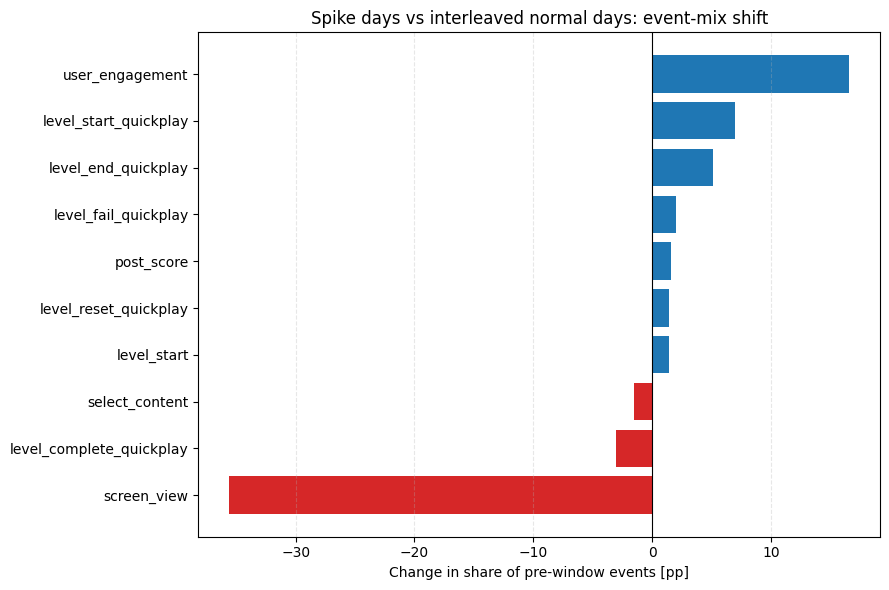

In [8]:
pp = ((pivoted['spike'] - pivoted['interleaved']) * 100).dropna()
pp = pp.reindex(pp.abs().sort_values(ascending=False).index)[:10].sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in pp]
ax.barh(pp.index, pp.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in share of pre-window events [pp]')
ax.set_title('Spike days vs interleaved normal days: event-mix shift')
ax.grid(alpha=0.3, linestyle='--', axis='x')
plt.tight_layout()
plt.show()

In [9]:
non_sv = 1 - pivoted.loc['screen_view']
inflation = non_sv['spike'] / non_sv['interleaved']
print('non-screen_view share, interleaved:', round(non_sv['interleaved'], 4))
print('non-screen_view share, spike:      ', round(non_sv['spike'], 4))
print('mechanical inflation factor:       ', round(inflation, 3))

non-screen_view share, interleaved: 0.5829
non-screen_view share, spike:       0.9387
mechanical inflation factor:        1.61


In [10]:
rare_events = ['firebase_campaign', 'dynamic_link_first_open',
               'dynamic_link_app_open', 'notification_foreground']

rare = sf[(sf['window_group'] == 'pre_window') & (sf['event_name'].isin(rare_events))]
per_label = rare.groupby(['event_name', 'label'])['n_events'].sum().unstack(fill_value=0)
display(per_label)

days_per_label = pd.Series({'spike': 7, 'interleaved': 7, 'anchor': 94})
display((per_label / days_per_label).round(2))

label,anchor,interleaved,spike
event_name,,,
dynamic_link_app_open,3,0,2
dynamic_link_first_open,0,0,3
firebase_campaign,344,20,102
notification_foreground,1,0,0


,anchor,interleaved,spike
event_name,,,
dynamic_link_app_open,0.03,0.00,0.29
dynamic_link_first_open,0.00,0.00,0.43
firebase_campaign,3.66,2.86,14.57
notification_foreground,0.01,0.00,0.00


In [11]:
# n_users is a per-row COUNT(DISTINCT): valid within a row, never summable across
# rows. Summing across DATES for a SINGLE event is valid — it yields user-days on
# which that event fired at least once. The rate below is therefore CONDITIONAL ON
# PARTICIPATION: events per user-day among users who fired that event, not a
# population average. Reach and intensity must be read together.
per_date = sf[(sf['window_group'] == 'pre_window') & (sf['label'] != 'anchor')]

rates = per_date.groupby(['label', 'event_name']).agg(
    n_events=('n_events', 'sum'),
    user_days=('n_users', 'sum')
).reset_index()
rates['events_per_participating_user_day'] = rates['n_events'] / rates['user_days']

focus = ['screen_view', 'user_engagement', 'level_start_quickplay',
         'level_complete_quickplay', 'select_content', 'post_score']
sub = rates[rates['event_name'].isin(focus)]

intensity = sub.pivot(index='event_name', columns='label',
                      values='events_per_participating_user_day')
reach = sub.pivot(index='event_name', columns='label', values='user_days')

print('INTENSITY — events per participating user-day')
display(intensity.round(2))
display((intensity['spike'] / intensity['interleaved']).round(2).sort_values())

print('REACH — user-days on which the event fired')
display(reach)
display((reach['spike'] / reach['interleaved']).round(2).sort_values())

INTENSITY — events per participating user-day


label,interleaved,spike
event_name,,
level_complete_quickplay,7.26,8.62
level_start_quickplay,14.34,13.40
post_score,7.09,7.99
screen_view,51.83,2.63
select_content,2.77,4.69
user_engagement,27.98,26.28


,0
event_name,
screen_view,0.05
level_start_quickplay,0.93
user_engagement,0.94
post_score,1.13
level_complete_quickplay,1.19
select_content,1.70


REACH — user-days on which the event fired


label,interleaved,spike
event_name,,
level_complete_quickplay,1584,274
level_start_quickplay,2044,4165
post_score,1792,2440
screen_view,2459,7854
select_content,2174,305
user_engagement,2499,5055


,0
event_name,
select_content,0.14
level_complete_quickplay,0.17
post_score,1.36
user_engagement,2.02
level_start_quickplay,2.04
screen_view,3.19
